In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("Data/loan_data.csv")
df["loan_status"]=df.loan_status.apply(lambda x : "Yes" if x==1 else "No" )
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,Yes
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,No
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,Yes
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,Yes
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,Yes
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,Yes
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,Yes
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,Yes


In [68]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

there are no missing values 

In [74]:
df.duplicated().sum()

np.int64(0)

there are no duplicated rows 

In [27]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000


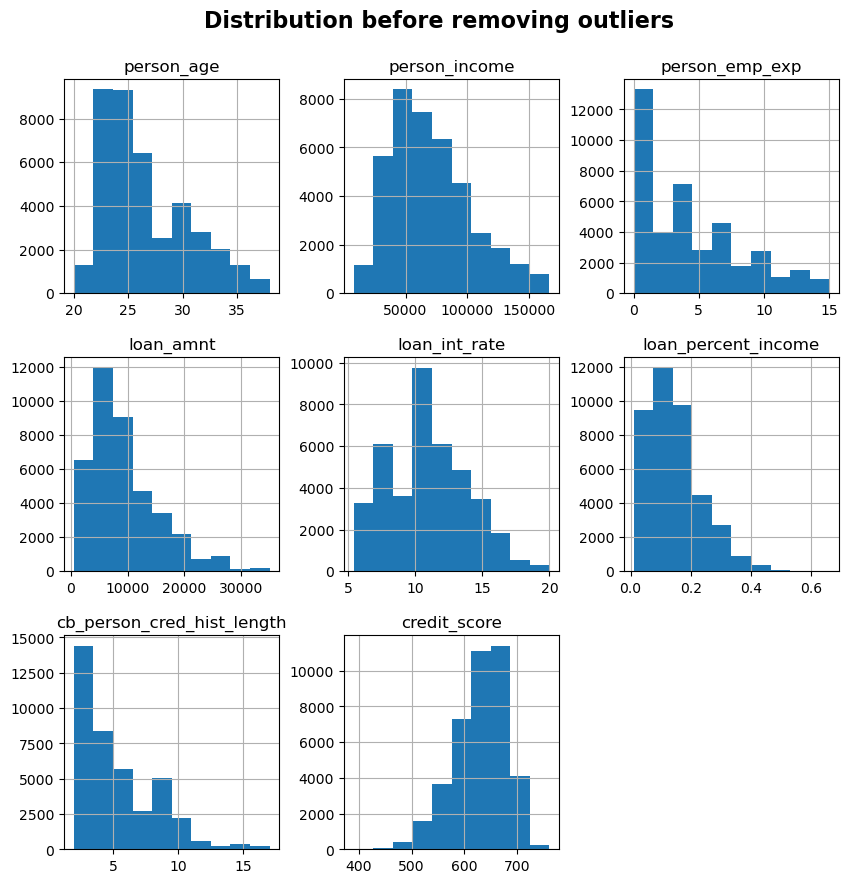

In [ ]:
#ploting all the distribution for numerical features 
ax=df.hist(figsize=(10,10))
plt.suptitle("Distribution before removing outliers",fontsize=16,y=.95,weight='bold')
plt.show()


From the above histrograms we can say :
1) features like person age , person income , person employee income have quite a lot of outliers and noices because of that we need to remove them from the dataset using IQR
2) Others features features are skewed to the right except credit score 
3) credit score is closest to a normal distribution

In [29]:
# making a funtion name "outlier_remover" for finding the index which are not outliers 
import numpy as np
def outlier_remover(x):
    #finding quantile range 
    Q3=np.nanquantile(a=x,q=.75)
    Q1=np.nanquantile(a=x,q=.25)

    #finding IQR

    IQR=Q3-Q1

    #upper bound and lower bound 
    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR

    #storing all the index that lies above the lower bound and below the upper bound for further use 
    normal_index=[]
    for index,val in enumerate(x):
        if(val>lower_bound and val<upper_bound):
            normal_index.append(index)
    
    return normal_index

In [66]:
# drop the rows that have outliers in features namely person age , person income , person employee income
columns_name=['person_age','person_income','person_emp_exp']

for col in columns_name:
    df=df.iloc[outlier_remover(df[col])]

df.shape

(38253, 14)

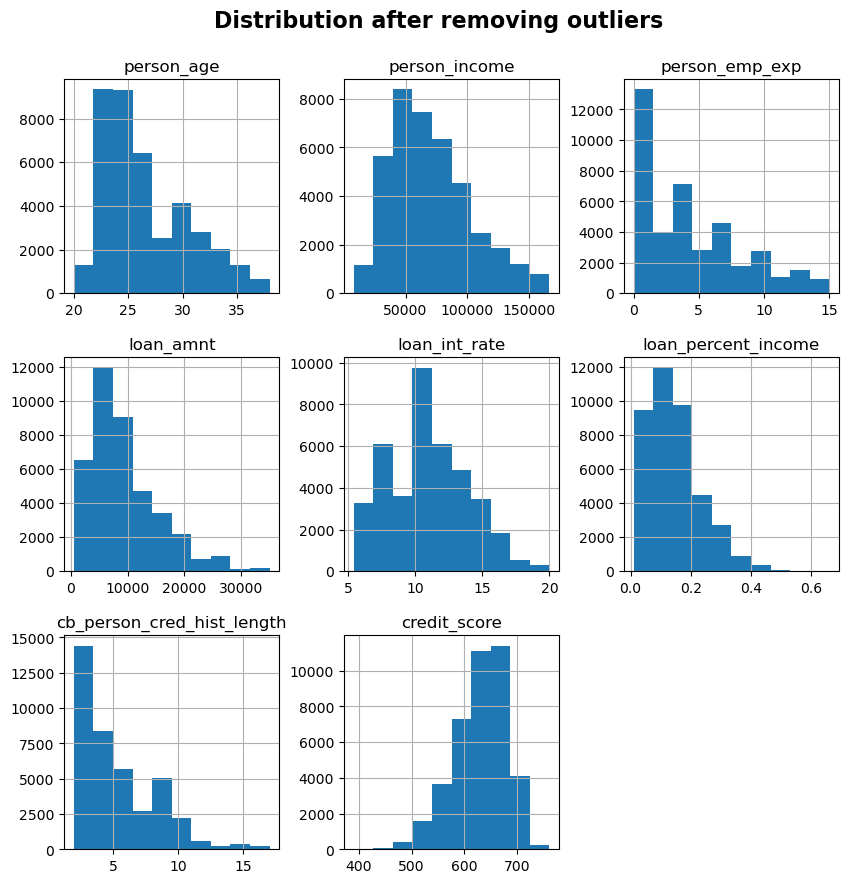

In [ ]:
#ploting all the distribution for numerical features after removing the outliers 
df.hist(figsize=(10,10))
plt.suptitle("Distribution after removing outliers",fontsize=16,y=.95,weight='bold')
plt.show()

From the above histrograms we can say :
1) Most of the outliers/noices have been removed from the features namely person age, person income, person employee income by using IQR and all of them are also skewed to right
2) Others features features are skewed to the right except credit score 
3) credit score is skewed to the left 

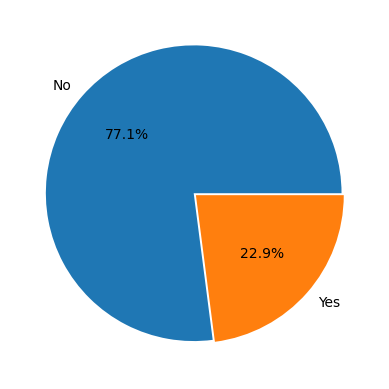

In [32]:
plt.pie(df.loan_status.value_counts(),labels=df.loan_status.value_counts().index,autopct="%1.1f%%",explode=(.01,.01))
plt.show()

The dataset is imbalanced because the number of rejected loans is significantly higher than approved loans. Class imbalance can affect classification model performance

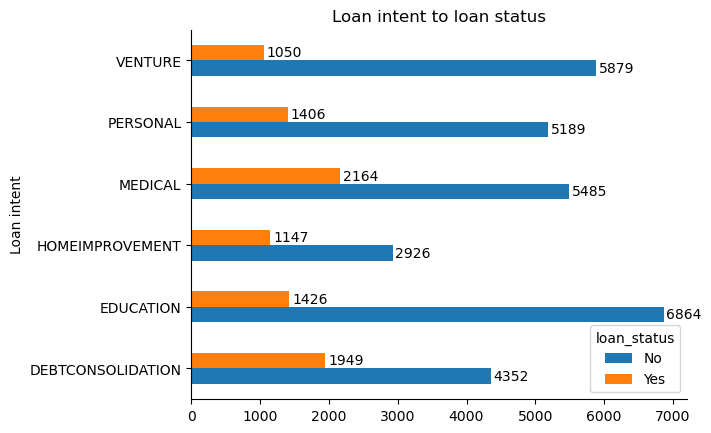

In [33]:
#making pivoit table related to loan intent and status of the loan 
loan_intent_use_by_loan_status=pd.pivot_table(df,index="loan_intent",columns="loan_status",aggfunc="size")

#making a bar chat 
ax=loan_intent_use_by_loan_status.plot(kind="barh")
sns.despine()

#adding label to the bar container 
ax.bar_label(ax.containers[0],padding=2)
ax.bar_label(ax.containers[1],padding=2)


#costomizing the label and plot title
plt.ylabel("Loan intent")
plt.title("Loan intent to loan status")
plt.show()

From the above graph we can conclude following point:
1) Education got the most rejection
2) Debtconsolidation got least rejection
3) Medical got most acceptance
4) Venture got least acceptance

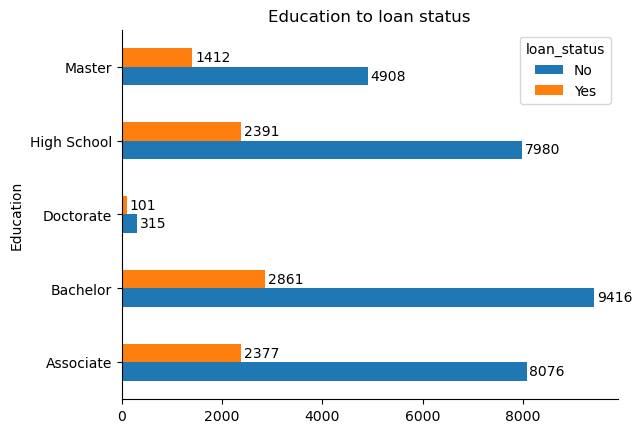

In [34]:
#making pivoit table related to person education and status of the loan 
person_education_by_loan_status=df.pivot_table(index="person_education",columns="loan_status",aggfunc="size")

#ploting the bar graph
ax=person_education_by_loan_status.plot(kind="barh")
sns.despine()

#adding label to the bar container 
ax.bar_label(ax.containers[0],padding=2)
ax.bar_label(ax.containers[1],padding=2)

#costomizing the label and plot title
plt.ylabel("Education")
plt.title("Education to loan status")
plt.show()



From the above graph we can say following points 
1) Person with doctorate apply least for loan and peson with bachelors apply the most 
2) Bachelors have the most number of loan application accepted and most amount of rejection too
3) Masters have the most amount of loan acceptance 

In [ ]:
#exported the dataset without outliers for data modeling also made loan status column into binary column 
df["loan_status"]=df.loan_status.apply(lambda x : 1 if x=="Yes" else 0 )
df.to_csv("Data/loan_data_without_outliers.csv",index=False)
